# SentencePiece

SentencePiece는 공백으로 단어를 미리 나누지 않은 원문에서 서브워드 어휘와 분할 규칙을 학습하는 토크나이저 프레임워크이다. 단어 전체를 어휘에 모두 저장하기 어려울 때, 자주 재사용되는 작은 조각으로 문장을 표현하여 OOV를 줄이기 위해 사용한다.

## 대표 학습 방식

- **Unigram**
  - 많은 후보 조각으로 시작한 뒤, 문장을 설명하는 데 도움이 적은 조각을 반복해서 제거한다. 최종적으로 남은 조각의 확률을 이용해 문장을 여러 방식으로 나눈 후보 중 가능성이 높은 분할을 선택한다. (*uni='하나로'만든다는 뜻. cf. 유니온, 합집합)
- **BPE(Byte Pair Encoding)**
  - 문자처럼 작은 단위에서 시작해 코퍼스에서 자주 붙어 나오는 이웃 조각 쌍을 반복해서 합친다. 합치는 순서가 학습 규칙으로 저장되며, 반복 횟수와 어휘 크기에 따라 조각의 크기가 달라진다.

## 주요 특징

- **원문 기반 학습**: 언어별 단어 분리기를 먼저 적용하지 않고 raw text에서 어휘를 학습한다.
- **공백 표시 `▁`**: 원문의 공백을 일반 문자처럼 보존하여 단어가 시작되는 위치와 디코딩 경계를 나타낸다. (파일명은 되도록이면 숫자,영어,언더바만 사용해야 함. 윈도우에서 띄어쓰기(공백)를 가능한 것처럼 보이게 해놓았지만 개발에 사용하게 되면 공백이 오류를 일으킴)
- **인코딩과 디코딩**: `encode()`는 문자열을 조각 또는 정수 ID로 바꾸고, `decode()`는 ID를 다시 문자열로 합친다. (인코딩은 문장을 서브워드로 쪼개는 것이고, 디코딩은 역으로 서브워드를 문장으로 합치는 것)

## 장점과 한계

- **장점**
  - 처음 보는 단어도 학습된 작은 조각의 조합으로 표현할 수 있어 단어 단위 어휘보다 OOV가 적다.
  - 언어별 전처리 규칙에 덜 의존하며 같은 모델 파일로 토큰화와 복원을 일관되게 수행할 수 있다.
- **한계**
  - 학습 코퍼스에 없는 문자는 OOV 대체 토큰이 될 수 있으므로 모든 입력을 표현한다고 보장하지 않는다.
  - 어휘와 분할 결과가 학습 데이터에 영향을 받으므로 실제 사용 도메인과 가까운 코퍼스가 필요하다.

## 대표 사용처

기계 번역, 언어 모델, 텍스트 분류처럼 문자열을 고정된 크기의 어휘 ID로 바꾸어 신경망에 입력하는 작업에 사용한다.

## 이번 노트북에서 확인할 내용

NSMC의 감성 레이블을 예측하는 것이 아니라 `document` 문자열의 반복 패턴으로 어휘 크기 30,000의 Unigram 토크나이저를 학습한다. `원문 → 조각 → 토큰 ID → 패딩된 입력`의 흐름과 ID를 다시 문자열로 복원하는 과정까지 확인한다.


## 01. 단어 OOV에서 서브워드로

(*서브워드로 토큰화하면 뭐가 좋은가 -> 우리가 직접 사전을 안 만들어도 된다. 서브워드 토큰화하면 알아서 다 쪼개주니까 그걸 그냥 때려넣으면 된다.)

**OOV(Out-Of-Vocabulary)** 는 입력에 등장했지만 토크나이저 어휘로 표현할 수 없는 항목이다. 단어 단위 토크나이저가 `재미있다`만 알고 있다면 새로운 활용형 `재미있지만` 전체를 미등록어로 처리할 수 있고, 이때 어미 `-지만`이 주는 정보도 모델 입력에서 사라진다.

**서브워드**는 단어보다 작고 문자 하나보다는 클 수 있는 재사용 가능한 문자열 조각이다. `재미있지만`을 `재미있`과 `지만`처럼 나누면 완전한 단어가 처음 등장해도 이미 학습한 조각의 ID로 표현할 수 있다. 따라서 모델은 단어 전체를 잃지 않고 어간과 어미의 일부 정보를 받을 수 있다.

SentencePiece는 이러한 조각을 미리 정해 두지 않고 학습 코퍼스의 문자열 분포에서 직접 선택한다. 먼저 NSMC의 리뷰 본문만 한 줄씩 모아 학습 파일을 만들고, 다음 절에서 그 파일로 Unigram 어휘를 학습한다.

서브워드는 OOV를 줄이지만 완전히 없애지는 않는다. 뒤의 OOV 절에서는 학습 어휘로 표현할 수 없는 문자가 어떤 ID로 전달되는지도 별도로 확인한다.


## 02. NSMC 학습 코퍼스 준비

토크나이저 학습은 정답 레이블을 맞히는 분류 학습과 다르다. 문장에 반복해서 등장하는 문자열을 바탕으로 어떤 조각을 어휘에 포함할지 결정하므로, 정답보다 충분한 원문 코퍼스가 필요하다.

아래 코드는 NSMC의 `ratings_train.txt`를 내려받아 SentencePiece가 읽을 `nsmc.txt`를 만든다.

- **입력 파일**: `id`, `document`, `label` 열을 가진 리뷰 150,000행의 TSV 파일이다.
- **학습 문자열**: 결측 문서 5개를 제거한 `document` 149,995개만 사용한다.
- **출력 파일**: 리뷰 하나를 한 줄에 저장한 UTF-8 텍스트 파일 `nsmc.txt`이다.

`id`와 `label`은 토크나이저 어휘를 만드는 데 사용하지 않는다. 다운로드 원본과 생성한 코퍼스는 `sentencepiece_artifacts`에 저장되며, 다음 모델 학습 셀이 이 경로의 `nsmc.txt`를 입력으로 사용한다.


In [1]:
%pip install sentencepiece

   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ---------------------------------------- 1.2/1.2 MB 12.6 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
from urllib.request import urlretrieve

import pandas as pd
import sentencepiece as spm

NSMC_TRAIN_URL = (
    "https://github.com/e9t/nsmc/raw/refs/heads/master/"
    "ratings_train.txt"
)

# 다운로드 파일과 SentencePiece 학습 결과는 노트북 기준 상대 폴더에 저장한다.
sp_workdir = Path("sentencepiece_artifacts")
sp_workdir.mkdir(parents=True, exist_ok=True)
train_path = sp_workdir / "ratings_train.txt"
corpus_path = sp_workdir / "nsmc.txt"

urlretrieve(NSMC_TRAIN_URL, train_path)

# document 결측 행을 제거한 뒤 문장만 한 줄씩 학습 코퍼스로 저장한다.
raw_data = pd.read_csv(train_path, sep="\t")
data = raw_data.dropna(subset=["document"]).reset_index(drop=True)
corpus_text = "\n".join(data["document"].astype(str))
corpus_path.write_text(corpus_text, encoding="utf-8")

print("다운로드 데이터 shape:", raw_data.shape)
print("열 이름:", raw_data.columns.tolist())
print("정제 데이터 shape:", data.shape)
print("document 결측치:", int(data["document"].isna().sum()))
print("학습 코퍼스 문장 수:", len(data))
print("학습 코퍼스 파일:", corpus_path.name)


다운로드 데이터 shape: (150000, 3)
열 이름: ['id', 'document', 'label']
정제 데이터 shape: (149995, 3)
document 결측치: 0
학습 코퍼스 문장 수: 149995
학습 코퍼스 파일: nsmc.txt


### NSMC 리뷰가 토큰 ID가 되는 흐름

그림은 원본 데이터가 모델 입력용 토큰 ID가 되기까지의 전체 흐름을 보여 준다. 먼저 결측 문서를 제거한 `document` 149,995개를 `nsmc.txt`에 저장하고, Unigram 학습이 이 코퍼스에서 30,000개 조각 어휘를 만든다.

학습이 끝난 뒤에는 새 리뷰가 사람이 읽는 조각과 모델이 사용하는 정수 ID로 변환된다. `label`은 이 흐름에 포함되지 않으므로 현재 작업은 감성 분류가 아니라 토크나이저 학습이다.

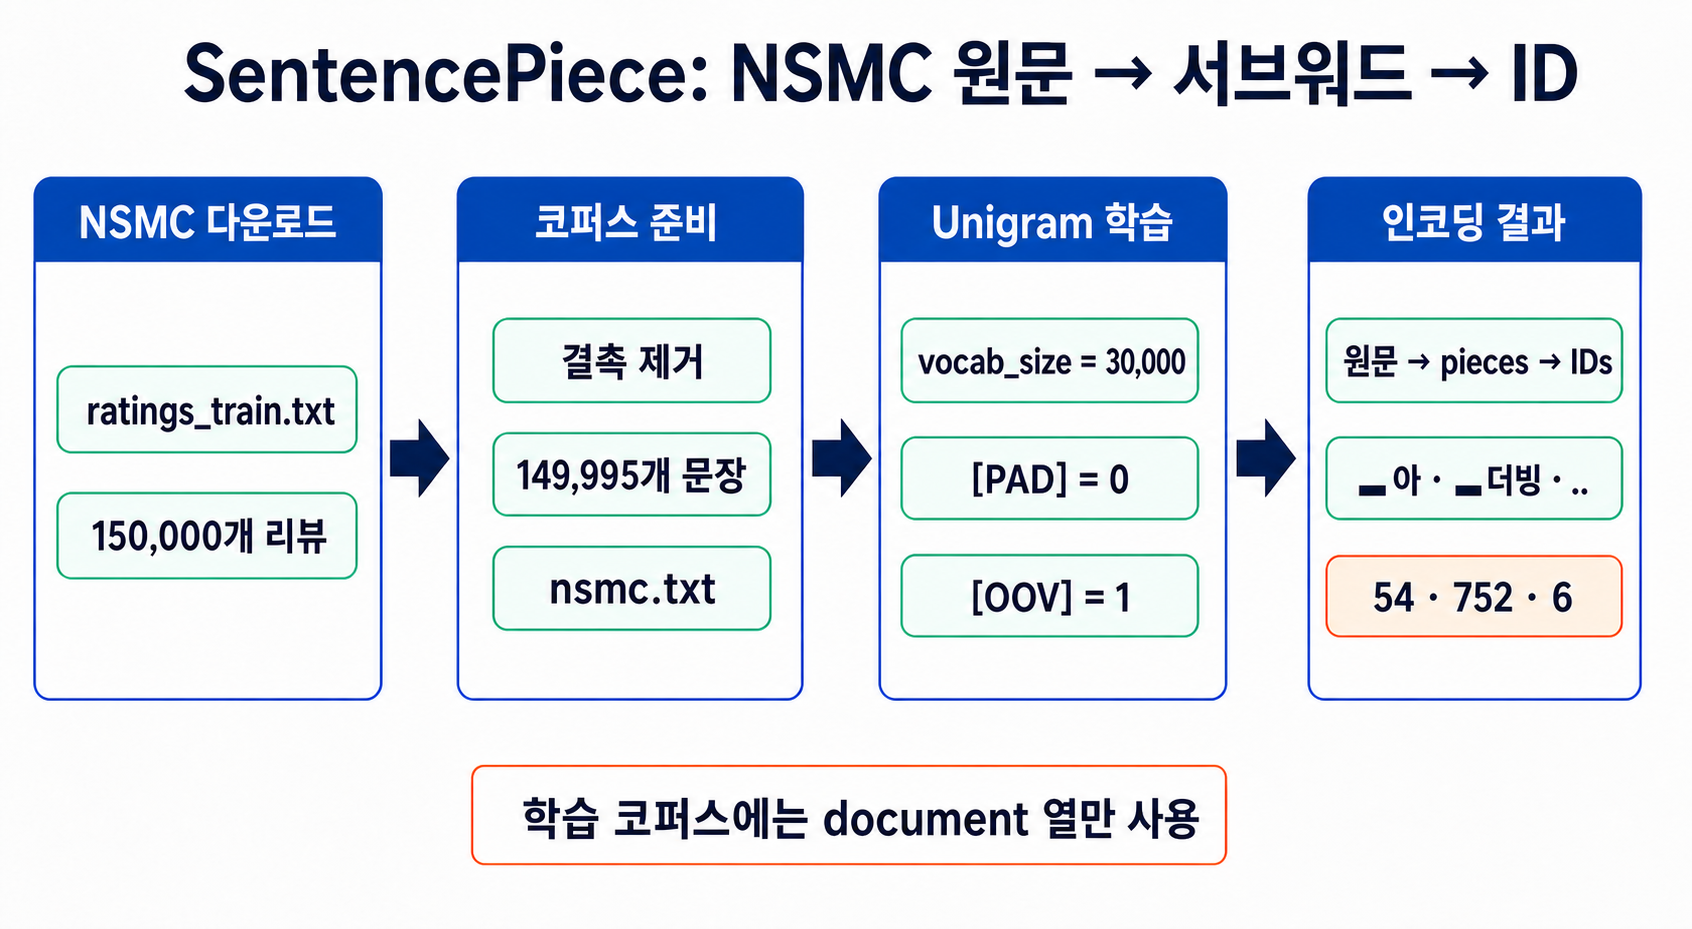


## 03. NSMC로 Unigram SentencePiece 모델 학습

`SentencePieceTrainer.train()`은 앞 절의 `nsmc.txt`를 읽어 서브워드 어휘와 분할 규칙을 학습한다. 결과는 인코딩에 사용하는 `.model`과 조각·점수를 사람이 읽을 수 있는 `.vocab` 파일로 저장된다.

이번에는 `model_type="unigram"`을 사용한다. Unigram은 많은 후보 조각에서 시작해 코퍼스를 설명하는 데 도움이 적은 조각을 줄여 가며, BPE처럼 빈번한 이웃 쌍을 차례로 병합하지 않는다.

주요 설정은 다음 결과를 결정한다.

- **`vocab_size=30000`**: 특수 토큰을 포함해 보관할 전체 조각 수이다. 값이 작으면 문장이 더 잘게 나뉘고, 지나치게 크면 어휘와 후속 임베딩 행이 불필요하게 늘 수 있다.
- **`pad_id=0`, `unk_id=1`**: 빈자리와 미등록 입력을 서로 다른 ID로 예약한다. (뒤에 bert에서 나오는 unk=언노운. OOV랑 같은 의미라고 생각해도 됨.)
- **`bos_id=2`, `eos_id=3`**: 문장 시작과 끝이 필요한 생성 모델에서 사용할 ID를 예약한다.

학습 셀은 실제 어휘 수가 30,000인지와 두 결과 파일이 생성되었는지 확인한다. 다음 셀에서는 모델에 저장된 특수 토큰의 ID가 설정값과 일치하는지 검사한다.


In [3]:
model_prefix = sp_workdir / "nsmc"

# NSMC 코퍼스로 어휘 30,000개의 Unigram 모델을 학습한다.
spm.SentencePieceTrainer.train(
    input=str(corpus_path), # 학습할 파일 nsmc.txt 경로를 지정
    model_prefix=str(model_prefix), # 학습된 모델을 저장할 경로
    vocab_size=30000, # 특수 토큰 포함 저장할 전체 서브워드 수
    model_type="unigram", # 서브워드 선택 방식을 unigram

    # 특수 토큰의 id 지정
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3,

    # 특수 토큰의 토큰 이름
    pad_piece="[PAD]",
    unk_piece="[OOV]",
    bos_piece="[BOS]",
    eos_piece="[EOS]",

    minloglevel=2, # 학습 로그를 2로 설정하여 줄임
)

model_path = Path(f"{model_prefix}.model")
vocab_path = Path(f"{model_prefix}.vocab")
sp_model = spm.SentencePieceProcessor(model_file=str(model_path))

print("실제 어휘 수:", sp_model.vocab_size())
print("모델 파일:", model_path.name, model_path.exists())
print("어휘 파일:", vocab_path.name, vocab_path.exists())


실제 어휘 수: 30000
모델 파일: nsmc.model True
어휘 파일: nsmc.vocab True


### PAD와 OOV 대체 토큰의 역할 구분

특수 토큰은 원문의 일반 조각과 다른 역할을 미리 예약한 어휘 항목이다. 특히 PAD와 OOV 대체 토큰을 같은 ID로 두면 attention mask가 실제 미등록 입력까지 빈자리로 오해할 수 있으므로 반드시 구분해야 한다.

- **`[PAD]` / ID 0**: 짧은 문장의 오른쪽 빈자리를 채우며 attention mask에서 0이 되는 위치이다.
- **`[OOV]` / ID 1**: 학습 어휘로 표현할 수 없는 입력을 대신하며 모델이 읽어야 하는 실제 입력이다.
- **`[BOS]`·`[EOS]` / ID 2·3**: 필요할 때 문장의 시작과 끝을 표시한다.

0~3은 모든 SentencePiece 모델의 공통 번호가 아니라 이 노트북에서 학습할 때 정한 값이다. 아래 코드는 모델 파일에 저장된 ID와 조각 문자열이 이 약속과 일치하는지 검사한다.


In [ ]:
# PAD, OOV, BOS, EOS에 예약된 실제 어휘 ID를 확인한다.
special_ids = {
    "PAD": sp_model.pad_id(),
    "OOV": sp_model.unk_id(),
    "BOS": sp_model.bos_id(),
    "EOS": sp_model.eos_id(),
}

for token_name, token_id in special_ids.items():
    print(f"{token_name}: {token_id}")

# 학습 설정과 모델 파일의 특수 토큰 ID가 같은지 불리언으로 출력한다.
expected_special_ids = {"PAD": 0, "OOV": 1, "BOS": 2, "EOS": 3}

special_piece_names = {
    name: sp_model.id_to_piece(token_id)
    for name, token_id in special_ids.items()
}
print("예약 ID 일치:", special_ids == expected_special_ids)
print("특수 토큰 표시:", special_piece_names)


## 04. NSMC 리뷰의 조각과 토큰 ID 확인

학습된 토크나이저는 같은 리뷰를 두 가지 형태로 반환할 수 있다. **piece**는 사람이 읽을 수 있는 문자열 조각이고, **토큰 ID**는 모델 어휘에서 그 조각이 저장된 행을 가리키는 정수이다. ID 숫자의 크기는 조각의 중요도나 등장 빈도와 무관하다.

아래 코드는 NSMC의 첫 리뷰 세 개를 각각 piece 목록과 ID 목록으로 인코딩한다. `pieces[i]`와 `token_ids[i]`는 같은 위치의 한 조각을 문자열과 정수로 표현한 값이며, 두 목록의 길이도 같아야 한다.

piece 목록은 분할 결과를 설명할 때 사용하고, ID 목록은 이후 임베딩 계층에 전달할 실제 모델 입력으로 사용한다. 다음 절에서는 이 대응 관계를 이용해 OOV가 발생한 정확한 위치를 찾는다.


In [4]:
sample_texts = data["document"].head(3).tolist()
sample_text = sample_texts[0]
print(sample_text)

for index, text in enumerate(sample_texts, start=1):
    # 같은 위치의 조각과 ID가 일대일로 대응한다.
    pieces = sp_model.encode(text, out_type=str) # 서브워드 형태로 변환
    token_ids = sp_model.encode(text, out_type=int) # 토큰 ID 형태로 변환

    print(f"\n리뷰 {index}: {text}")
    print("  조각:", pieces)
    print("  ID:", token_ids)
    print("  토큰 수:", len(token_ids))


아 더빙.. 진짜 짜증나네요 목소리

리뷰 1: 아 더빙.. 진짜 짜증나네요 목소리
  조각: ['▁아', '▁더빙', '..', '▁진짜', '▁짜증나네요', '▁목소리']
  ID: [54, 949, 6, 25, 16095, 1407]
  토큰 수: 6

리뷰 2: 흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
  조각: ['▁흠', '...', '포스터보고', '▁초딩영화', '줄', '....', '오버', '연기', '조차', '▁가볍지', '▁않', '구나']
  ID: [1300, 7, 24864, 18767, 422, 47, 18179, 400, 1146, 6461, 1073, 417]
  토큰 수: 12

리뷰 3: 너무재밓었다그래서보는것을추천한다
  조각: ['▁너무', '재밓', '었다', '그래서', '보는것', '을', '추천', '한다']
  ID: [18, 24112, 636, 2786, 10500, 16, 2134, 287]
  토큰 수: 8


### 처음 본 표현의 OOV 위치 확인

서브워드는 처음 본 단어를 이미 아는 작은 조각으로 나누어 OOV를 줄이지만, 학습 코퍼스의 문자 범위를 벗어난 모든 입력까지 보장하지는 않는다. 어떤 조각으로도 표현할 수 없는 위치에는 `unk_id()`가 반환하는 OOV 대체 ID가 들어간다.

아래 문장은 NSMC에서 보기 어려운 `🧪` 문자를 포함한다. piece 목록에는 원문의 표면 문자가 보일 수 있지만, 같은 위치의 ID가 1이면 모델에는 해당 문자의 전용 ID가 아니라 `[OOV]` ID가 전달된 것이다.

출력의 OOV 위치는 0부터 시작하는 인덱스이다. `[3]`이면 네 번째 piece와 네 번째 ID를 함께 읽어 어떤 입력이 표현되지 못했는지 판단한다.


In [5]:
unseen_text = "영화가 재미있지만 🧪 표현은 낯설다"

pieces = sp_model.encode(unseen_text, out_type=str)
token_ids = sp_model.encode(unseen_text, out_type=int)
oov_id = sp_model.unk_id() # SentencePeiceTrainer 훈련 시 등록된 unk_id 특수 토큰 속성 값 얻어오기

# OOV ID가 나타난 위치만 모은다.
oov_positions = [
    index
    for index, token_id in enumerate(token_ids)
    if token_id == oov_id
]

print("원문:", unseen_text)
print("조각:", pieces)
print("ID:", token_ids)
print("OOV 위치:", oov_positions)


원문: 영화가 재미있지만 🧪 표현은 낯설다
조각: ['▁영화가', '▁재미있지만', '▁', '🧪', '▁표현', '은', '▁낯설', '다']
ID: [70, 20953, 5, 1, 847, 21, 13868, 22]
OOV 위치: [3]


### ID를 다시 문자열로 복원하기

디코딩은 모델의 예측을 되돌리는 학습 과정이 아니라, 토큰 ID를 어휘 조각으로 조회해 문자열로 결합하는 토큰화의 역변환이다.

아래 코드는 `원문 → ID 목록 → 복원문` 순서로 같은 첫 리뷰를 변환한다. `decode()`가 조각의 `▁` 경계를 다시 공백으로 바꾸고, OOV가 없는 일반 리뷰의 내용이 원문과 동일하게 복원되는지 확인한다. OOV ID가 포함되거나 정규화로 문자가 바뀐 입력은 원문과 완전히 같지 않을 수 있다.


In [7]:
# 첫 리뷰를 ID로 바꾼 뒤 다시 문자열로 복원한다.

# sample_text = 아 더빙.. 진짜 짜증나네요 목소리
# -> 토큰 ID 목록으로 변환
sample_ids = sp_model.encode(sample_text, out_type=int)

# 토큰 ID 목록 -> 원문 형태로 변경
decoded_text = sp_model.decode(sample_ids)

same_after_decode = sample_text == decoded_text

print("원문:", sample_text)
print("ID:", sample_ids)
print("복원문:", decoded_text)
print("원문과 동일:", same_after_decode)

원문: 아 더빙.. 진짜 짜증나네요 목소리
ID: [54, 949, 6, 25, 16095, 1407]
복원문: 아 더빙.. 진짜 짜증나네요 목소리
원문과 동일: True


## 05. 패딩과 attention mask

배치 학습은 여러 문장을 하나의 직사각형 텐서로 처리하므로 문장마다 토큰 수가 달라도 같은 길이로 맞춰야 한다. 짧은 문장에는 PAD를 붙이고, 너무 긴 문장은 정한 최대 길이에서 자른다.

아래 코드는 NSMC 첫 리뷰 세 개에서 다음 두 배열을 만든다.

- **`padded_ids`**: 실제 토큰 뒤에 PAD ID 0을 붙여 각 행을 길이 20으로 만든 모델 입력이다.
- **`attention_mask`**: 실제 토큰과 OOV 위치는 1, 내용이 없는 PAD 위치만 0으로 표시한 배열이다.

두 배열의 개념적 shape는 모두 `(배치 3, 토큰 위치 20)`이다. 원래 토큰 수가 20보다 크면 뒤쪽 조각이 잘리므로, 출력에서는 PAD 수뿐 아니라 원래 길이와 잘린 조각도 함께 확인한다.


In [9]:
batch_sentences = data['document'].head(3).tolist() # 리뷰 3개
max_length = 20 # 토큰 위치 수 20 == 토큰 20개

# [PAD] 값 얻어오기
pad_id = sp_model.pad_id()

# 리뷰->토큰ID 목록으로 변환
original_encoded_rows = [
    sp_model.encode(sentence, out_type=int)
    for sentence in batch_sentences
]

# 토큰 ID 목록의 개수가 20개 초과 시 잘라내기
encoded_rows = [
    token_ids[:max_length]
    for token_ids in original_encoded_rows
]

# 토큰 ID 목록에 PAD 추가 -> (3,20) 형태 맞추기
padded_ids = [
    token_ids + [pad_id] * (max_length - len(token_ids))
    for token_ids in original_encoded_rows
]

# attention_mask 만들기 : 값이 PAD이면 0, 나머지 1
attention_mask = [
    [0 if token_id == pad_id else 1   # 해석순서 3
     for token_id in row]  # 해석순서 2
    for row in padded_ids   # 해석순서 1
]


for sentence, original_ids, token_ids, mask in zip(
    batch_sentences,
    original_encoded_rows,
    padded_ids,
    attention_mask,
):
    # [max_length:]는 20번째 인덱스부터 끝까지, 즉 앞에서 잘려 나간 ID만 선택
    omitted_ids = original_ids[max_length:]

    # 잘린 ID를 사람이 읽는 조각으로 바꾸어 max_length 때문에 사라진 내용을 직접 확인
    omitted_pieces = [
        sp_model.id_to_piece(token_id)
        for token_id in omitted_ids
    ]

    print("\n문장:", sentence)
    print("ID:", token_ids)
    print("mask:", mask)
    print("원본 토큰 수:", len(original_ids))

    # mask에는 실제 토큰 1과 PAD 0만 있으므로 합계가 잘리지 않고 남은 실제 토큰 수
    print("보존 토큰 수:", sum(mask))

    # 빈 목록은 False이고 잘린 ID가 하나라도 있는 목록은 True이므로 잘림 여부로 바로 표시
    print("잘림 여부:", bool(omitted_ids))
    if omitted_pieces:
        print("잘린 조각:", omitted_pieces)


문장: 아 더빙.. 진짜 짜증나네요 목소리
ID: [54, 949, 6, 25, 16095, 1407, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
mask: [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
원본 토큰 수: 6
보존 토큰 수: 6
잘림 여부: False

문장: 흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나
ID: [1300, 7, 24864, 18767, 422, 47, 18179, 400, 1146, 6461, 1073, 417, 0, 0, 0, 0, 0, 0, 0, 0]
mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]
원본 토큰 수: 12
보존 토큰 수: 12
잘림 여부: False

문장: 너무재밓었다그래서보는것을추천한다
ID: [18, 24112, 636, 2786, 10500, 16, 2134, 287, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
mask: [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
원본 토큰 수: 8
보존 토큰 수: 8
잘림 여부: False


## 06. 결과에서 주목할 점

이 노트북의 결과는 파일 생성 여부만 확인하는 데서 끝나지 않는다. 코퍼스에서 학습한 어휘가 새 문자열을 올바른 조각과 모델 입력으로 바꾸는지 다음 순서로 연결해 읽는다.

- 결측 제거 후 `document` 149,995개만 `nsmc.txt`에 들어가고 실제 어휘 수가 30,000인지 확인한다.
- 같은 위치의 piece와 ID가 일대일로 대응하며 `[PAD]`와 `[OOV]`가 서로 다른 ID인지 확인한다.
- 일반 리뷰의 ID를 디코딩했을 때 원문이 복원되고, 미등록 문자는 OOV 위치로 분리되는지 확인한다.
- 길이 20의 `padded_ids`와 `attention_mask`에서 PAD 위치만 mask 0인지 확인한다.

이후 분류 모델은 `padded_ids`로 임베딩 벡터를 조회하고 `attention_mask`로 내용이 없는 PAD가 문장 표현에 섞이지 않게 한다. 토크나이저 단계에서 중요한 문자가 반복해서 OOV가 되거나 문장이 지나치게 잘게 나뉘면, 후속 모델을 오래 학습해도 이미 손실된 입력 정보를 복구하기 어렵다.

아래 그림은 조각과 ID의 위치 대응, OOV 대체, 디코딩, PAD와 mask를 한 흐름으로 연결한다. 그림의 파란 사각형은 실제 SentencePiece 출력의 `▁`(공백 경계 표시)를 시각화한 것이다. `padded_ids`와 `attention_mask`는 같은 `(3, 20)` 구조이며 실제 토큰은 mask 1, PAD만 mask 0이 된다.

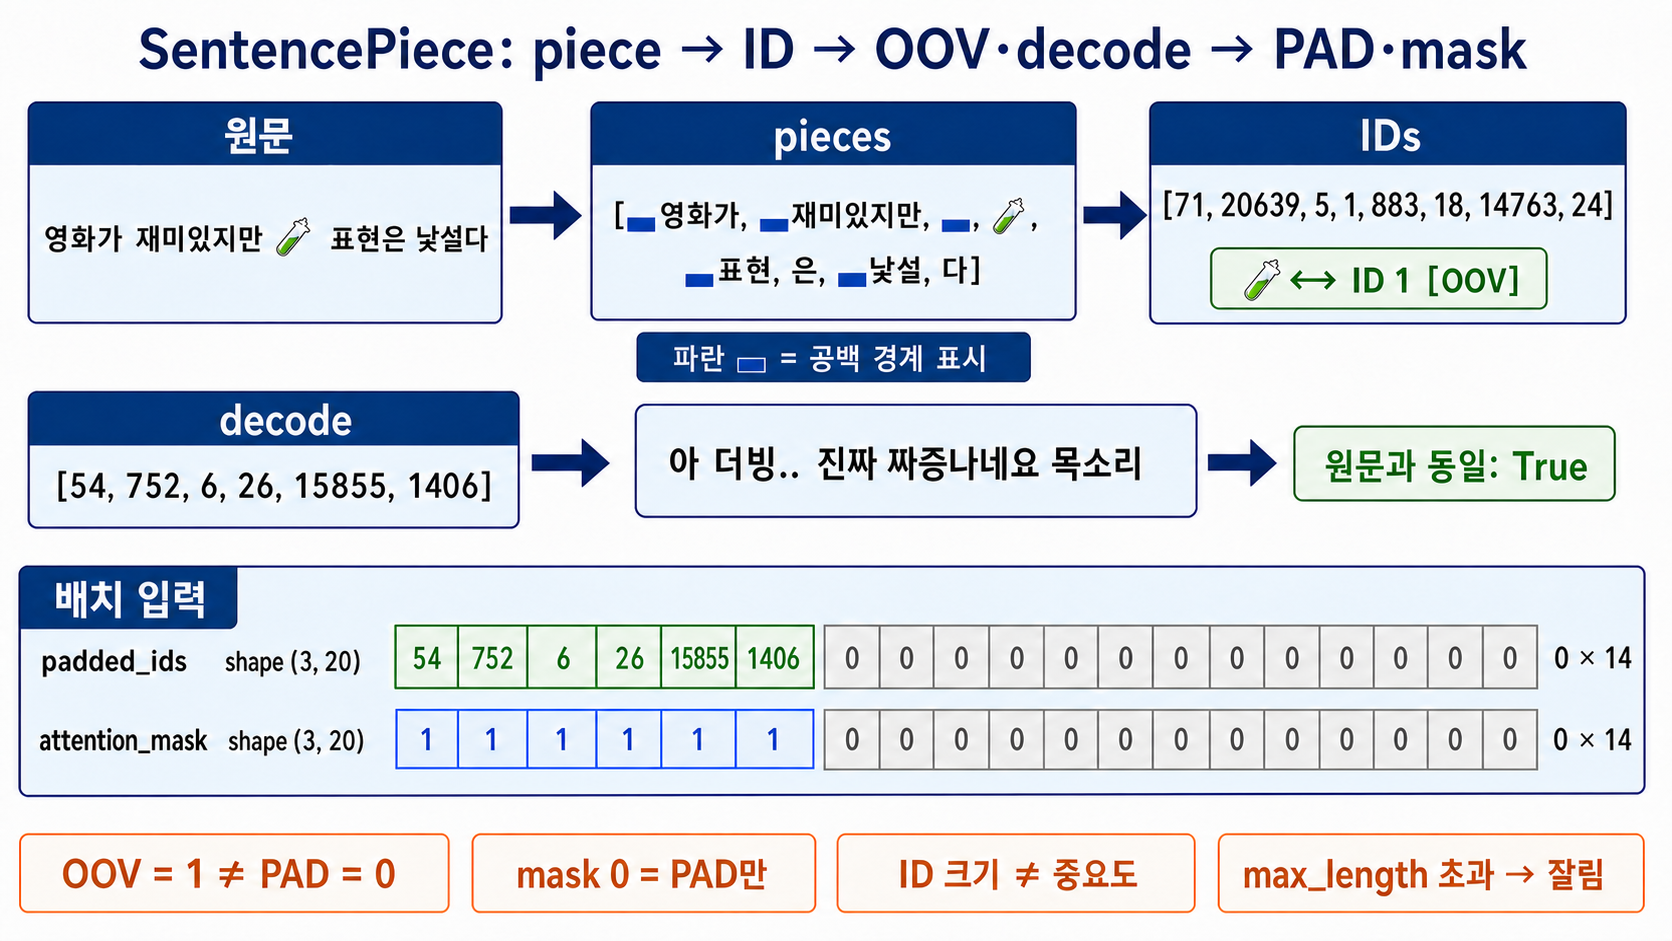
